<a href="https://colab.research.google.com/github/riack16/Proyecto-rendimiento-acad-mico/blob/main/S100_Equipo4_ParteI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (4, 2), "figure.dpi": 80,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 9})

df = pd.read_csv("StudentPerformanceFactors.csv")


print("Filas y columnas:", df.shape)

Filas y columnas: (6607, 20)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6605 non-null   float64
 1   Attendance                  6605 non-null   float64
 2   Parental_Involvement        6606 non-null   object 
 3   Access_to_Resources         6605 non-null   object 
 4   Extracurricular_Activities  6605 non-null   object 
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6606 non-null   object 
 8   Internet_Access             6606 non-null   object 
 9   Tutoring_Sessions           6606 non-null   float64
 10  Family_Income               6606 non-null   object 
 11  Teacher_Quality             6528 non-null   object 
 12  School_Type                 6605 non-null   object 
 13  Peer_Influence              6606 

In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6605.000000,6605.000000,6607.00000,6607.000000,6606.000000,6604.000000,6605.000000
mean,19.973808,79.948978,7.02906,75.070531,1.493642,2.967293,67.215291
std,5.995209,11.736506,1.46812,14.399784,1.230648,1.031015,4.217186
min,0.000000,-91.000000,4.00000,50.000000,0.000000,0.000000,-65.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
fuera_rango = df[ (df['Exam_Score'] < 0) | (df['Exam_Score'] > 100) | (df['Attendance'] < 0) ]

resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Filas_Totales': len(df),
    'Nulos': df.isnull().sum(),
}
)
resumen['Media'] =  round( df.select_dtypes(include='number').mean() , 1)
resumen['Mediana']= round( df.select_dtypes(include='number').median() , 1)
resumen['Minimo'] = round( df.select_dtypes(include='number').min(), 1)
resumen['Maximo'] = round( df.select_dtypes(include='number').max(),1)
resumen ['%_Falta'] = round( resumen ['Nulos'] / resumen['Filas_Totales'] * 100, 2)
Resumenf = resumen.drop(columns=['Filas_Totales','Nulos'])
pd.set_option('display.expand_frame_repr', False)
print(Resumenf)

print('╔══════════════════════════════════════════════════════╗')
print('║           RESUMEN DE DE DATOS                        ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Total de filas originales            : {len(df):>6}       ║')
print(f'║  Total de Columnas originales         : {len(df.columns):>6}       ║')
print(f'║  Valores nulos                        : {df.isnull().sum().sum():>6}       ║')
print(f'║  Valores inconsistentes               : {len(fuera_rango):>6}       ║')
print(f'║  Valores duplicados                   : {len(df[df.duplicated()]):>6}       ║')

print('╚══════════════════════════════════════════════════════╝')

                               Tipo  Media  Mediana  Minimo  Maximo  %_Falta
Hours_Studied               float64   20.0     20.0     0.0    44.0     0.03
Attendance                  float64   79.9     80.0   -91.0   100.0     0.03
Parental_Involvement         object    NaN      NaN     NaN     NaN     0.02
Access_to_Resources          object    NaN      NaN     NaN     NaN     0.03
Extracurricular_Activities   object    NaN      NaN     NaN     NaN     0.03
Sleep_Hours                   int64    7.0      7.0     4.0    10.0     0.00
Previous_Scores               int64   75.1     75.0    50.0   100.0     0.00
Motivation_Level             object    NaN      NaN     NaN     NaN     0.02
Internet_Access              object    NaN      NaN     NaN     NaN     0.02
Tutoring_Sessions           float64    1.5      1.0     0.0     8.0     0.02
Family_Income                object    NaN      NaN     NaN     NaN     0.02
Teacher_Quality              object    NaN      NaN     NaN     NaN     1.20

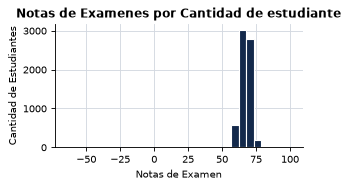

In [7]:
plt.hist(df["Exam_Score"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Notas de Examen")
plt.ylabel("Cantidad de Estudiantes")
plt.title("Notas de Examenes por Cantidad de estudiante")
plt.show()

## 1. Limpieza y preparación de datos


**- 1 Eliminar Valores fuera de rango:** `Attendance` tiene valores negativos (mínimo -91) y `Exam_Score` tiene valores fuera de [0,100] (min -65, max 101). Para `Attendance` asumimos que el signo negativo es un error de captura y tomamos el valor absoluto (recuperamos el dato en vez de perderlo). Para `Exam_Score` no hay una corrección obvia, así que lo tratamos como dato faltante y lo imputamos más adelante.


In [8]:
# --- Corrección de valores fuera de rango ---
df['Attendance'] = df['Attendance'].abs()
df.loc[df['Attendance'] > 100, 'Attendance'] = np.nan

df.loc[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100), 'Exam_Score'] = np.nan

print("Nulos en Attendance tras la corrección:", df['Attendance'].isna().sum())
print("Nulos en Exam_Score tras la corrección:", df['Exam_Score'].isna().sum())


Nulos en Attendance tras la corrección: 2
Nulos en Exam_Score tras la corrección: 4


**-2 Valores faltantes:**  los datos nulos o valores faltantes en las columnas numéricas se reempalzan por la mediana de esa columna ya que es como la menos susceptible a valores muy grandes o muy pequeños y por lo tanto se puede sacar una informacion mas precisa.


In [9]:
df_clean = df.copy()

num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
            'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
            'School_Type', 'Peer_Influence', 'Learning_Disabilities',
            'Parental_Education_Level', 'Distance_from_Home', 'Gender']

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Nulos restantes en todo el dataset:", df_clean.isnull().sum().sum())


Nulos restantes en todo el dataset: 0


**-3 Codificación:** varias categóricas tienen un orden natural (`Low < Medium < High`, etc.), así que se codifican como enteros ordinales en vez de one-hot, para no perder esa información de orden ni inflar la dimensionalidad. Las binarias (`Yes/No`, `Male/Female`, etc.) se mapean directamente a 0/1. ¿Por qué es necesaria? los modelos de scikit-learn que vas a usar más adelante (Regresión Lineal, KNN, Árbol de Decisión) solo aceptan números como entrada.


In [10]:
# --- Codificación de variables categóricas ---
map_low_med_high = {'Low': 0, 'Medium': 1, 'High': 2}
ordinal_maps = {
    'Parental_Involvement': map_low_med_high,
    'Access_to_Resources': map_low_med_high,
    'Motivation_Level': map_low_med_high,
    'Family_Income': map_low_med_high,
    'Teacher_Quality': map_low_med_high,
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
}
for col, mapping in ordinal_maps.items():
    df_clean[col] = df_clean[col].map(mapping)

binary_maps = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'School_Type': {'Public': 0, 'Private': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'Gender': {'Male': 0, 'Female': 1},
}
for col, mapping in binary_maps.items():
    df_clean[col] = df_clean[col].map(mapping)

# Por si alguna categoría nueva/mal escrita no quedó mapeada, imputamos con la moda
df_clean[list(ordinal_maps) + list(binary_maps)] = (
    df_clean[list(ordinal_maps) + list(binary_maps)]
    .apply(lambda s: s.fillna(s.mode()[0]))
)

print(df_clean.dtypes.value_counts())
df_clean.head()


int64      15
float64     5
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,0,2,0,7,73,0,1,0.0,0,1,0,2,3.0,0,0,0,0,67.0
1,19.0,64.0,0,1,0,8,59,0,1,1.0,1,1,0,0,4.0,0,1,1,1,61.0
2,24.0,98.0,1,1,1,7,91,1,1,2.0,1,1,0,1,4.0,0,2,0,0,74.0
3,29.0,89.0,0,1,1,8,98,1,1,1.0,1,1,0,0,4.0,0,0,1,0,71.0
4,19.0,92.0,1,1,1,6,65,1,1,3.0,1,2,0,1,4.0,0,1,0,1,70.0


## 2. Análisis exploratorio de datos (EDA)


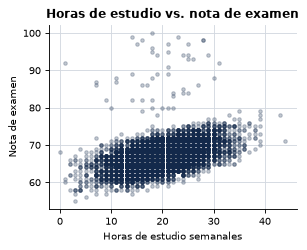

In [11]:
plt.figure(figsize=(4, 3))
plt.scatter(df_clean['Hours_Studied'], df_clean['Exam_Score'], alpha=0.25, color=AZUL, s=10)
plt.xlabel('Horas de estudio semanales')
plt.ylabel('Nota de examen')
plt.title('Horas de estudio vs. nota de examen')
plt.show()


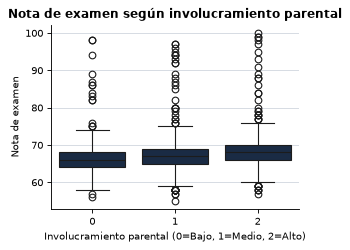

In [12]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df_clean, x='Parental_Involvement', y='Exam_Score', color=AZUL)
plt.xlabel('Involucramiento parental (0=Bajo, 1=Medio, 2=Alto)')
plt.ylabel('Nota de examen')
plt.title('Nota de examen según involucramiento parental')
plt.show()


In [13]:
# Tabla de estadísticos descriptivos de las variables numéricas ya limpias
df_clean[num_cols].describe().round(2)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.97,79.98,7.03,75.07,1.49,2.97,67.23
std,5.99,11.55,1.47,14.40,1.23,1.03,3.87
min,0.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,100.00


**Resultados**

Grafico 1: Horas de estudio vs. nota
La tendencia es clara: mientras más estudias, mejor te va… pero no es una garantía. El gráfico muestra que con pocas horas (menos de 10) casi nadie supera los 80 puntos. Sin embargo, incluso quienes estudian mucho (25 a 40 horas) a veces terminan con notas bajas, en el rango de 60–70. En otras palabras, estudiar ayuda, pero no explica todo: hay otros factores que influyen en el desempeño, lo cual tiene sentido porque el dataset incluye muchas más variables además de las horas de estudio.

Grafico 2: Involucramiento parental (boxplot)  
Aquí se ve un efecto leve: a medida que el apoyo de los padres pasa de bajo a alto, la mediana de las notas sube un poco y el rango superior llega más cerca del 100. Sin embargo, las tres categorías se solapan bastante, lo que indica que el impacto existe pero no es tan fuerte. Es más un empujón que un cambio radical.

Tabla describe() después de la limpieza
La depuración surtió efecto: ya no aparecen valores imposibles como asistencias negativas o notas de -65 y 101. Ahora Attendance va de 60 a 100 y Exam_Score de 55 a 100. Los promedios y desviaciones estándar apenas cambiaron, porque los errores eran pocos y no afectaban la mayoría de los datos. Lo importante es que ahora el dataset refleja mejor la realidad y es más confiable para el análisis.
